# Task 2: Exploratory Data Analysis (EDA) — Titanic Dataset
**AI & ML Internship**

**Objective:** Understand the data using statistics and visualizations.

**Tools:** Pandas, Matplotlib, Seaborn, Plotly

## 1. Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)


## 2. Load Dataset
Dataset file is kept in the same folder as this notebook.

In [22]:
data_path = Path.cwd() / "Titanic-Dataset.csv"
df = pd.read_csv(data_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Basic Info & Structure

In [23]:
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()

Shape: (891, 12)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [24]:
print("Missing values per column:\n")
df.isnull().sum()

Missing values per column:



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 4. Summary Statistics
Generate mean, median, std, min, max, quartiles for numeric features.

In [25]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
# Median separately (describe() only gives 50% via quantile, this is explicit)
numeric_cols = df.select_dtypes(include=[np.number]).columns
summary = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'std': df[numeric_cols].std(),
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max(),
    'skew': df[numeric_cols].skew()
})
summary

,mean,median,std,min,max,skew
PassengerId,446.000000,446.0000,257.353842,1.00,891.0000,0.000000
Survived,0.383838,0.0000,0.486592,0.00,1.0000,0.478523
Pclass,2.308642,3.0000,0.836071,1.00,3.0000,-0.630548
Age,29.699118,28.0000,14.526497,0.42,80.0000,0.389108
SibSp,0.523008,0.0000,1.102743,0.00,8.0000,3.695352
Parch,0.381594,0.0000,0.806057,0.00,6.0000,2.749117
Fare,32.204208,14.4542,49.693429,0.00,512.3292,4.787317


## 5. Categorical Feature Overview

In [27]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- Name ---
Name
Braund, Mr. Owen Harris                            1
Boulos, Mr. Hanna                                  1
Frolicher-Stehli, Mr. Maxmillian                   1
Gilinski, Mr. Eliezer                              1
Murdlin, Mr. Joseph                                1
Rintamaki, Mr. Matti                               1
Stephenson, Mrs. Walter Bertram (Martha Eustis)    1
Elsbury, Mr. William James                         1
Bourke, Miss. Mary                                 1
Chapman, Mr. John Henry                            1
Name: count, dtype: int64

--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64

--- Ticket ---
Ticket
347082          7
CA. 2343        7
1601            7
3101295         6
CA 2144         6
347088          6
S.O.C. 14879    5
382652          5
LINE            4
PC 17757        4
Name: count, dtype: int64

--- Cabin ---
Cabin
NaN            687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
D        

## 6. Histograms for Numeric Features

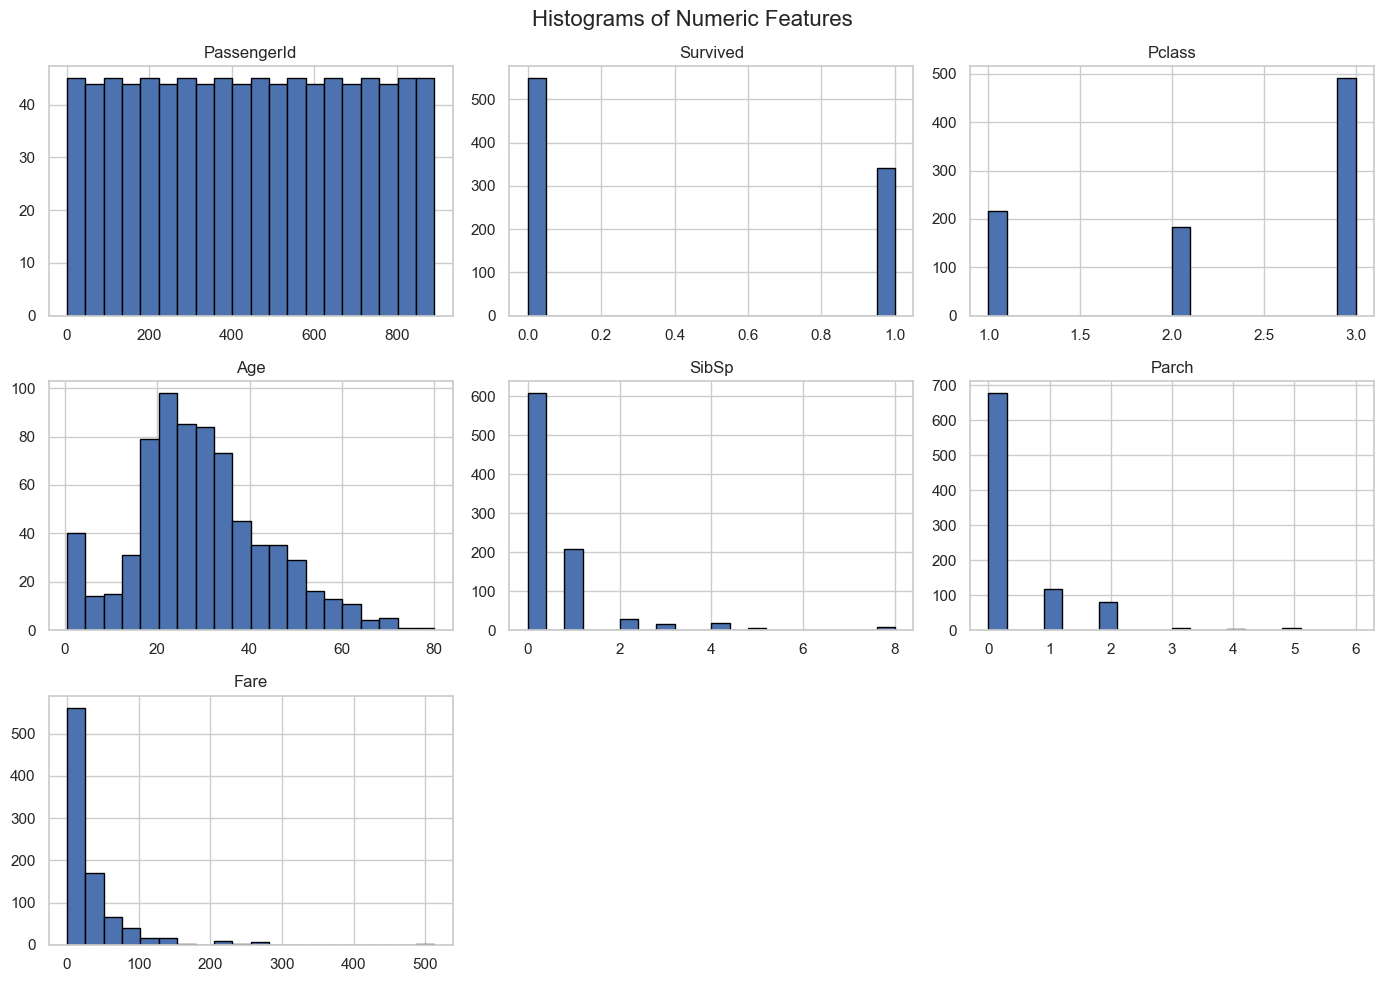

In [28]:
df[numeric_cols].hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

### Age Distribution by Survival

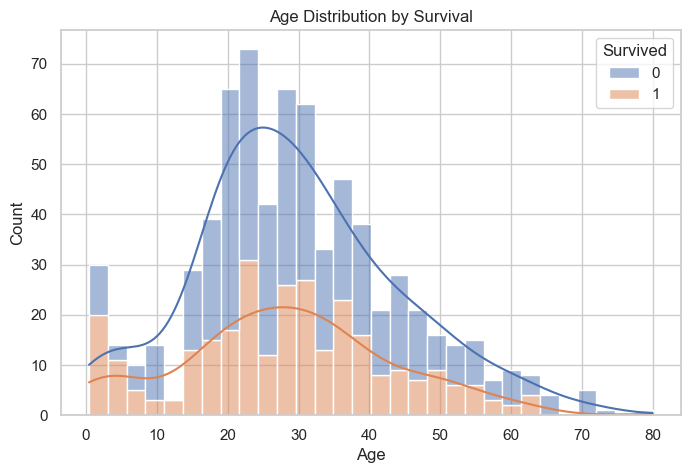

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, multiple='stack')
plt.title("Age Distribution by Survival")
plt.show()

## 7. Boxplots for Numeric Features (Outlier Detection)

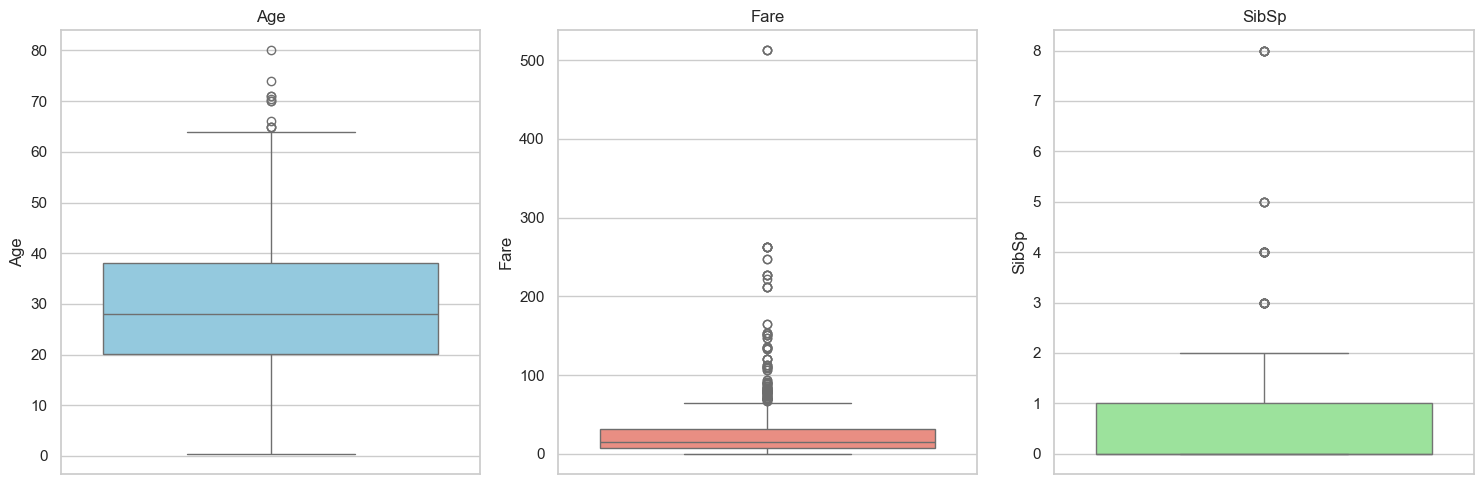

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Age')
sns.boxplot(y=df['Fare'], ax=axes[1], color='salmon')
axes[1].set_title('Fare')
sns.boxplot(y=df['SibSp'], ax=axes[2], color='lightgreen')
axes[2].set_title('SibSp')
plt.tight_layout()
plt.show()

### Fare by Passenger Class

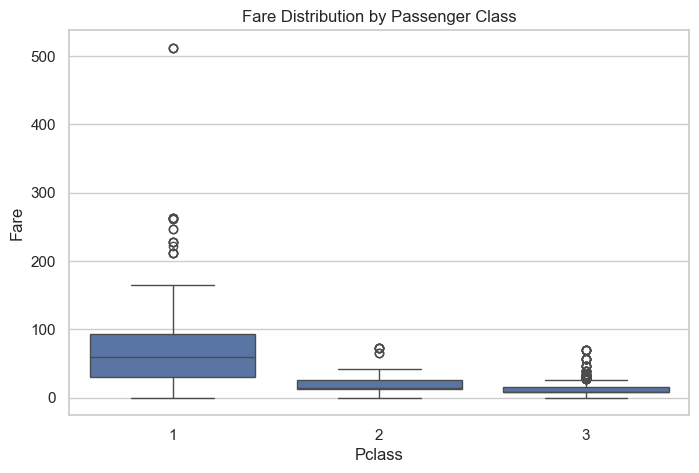

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Fare')
plt.title("Fare Distribution by Passenger Class")
plt.show()

## 8. Correlation Matrix / Heatmap

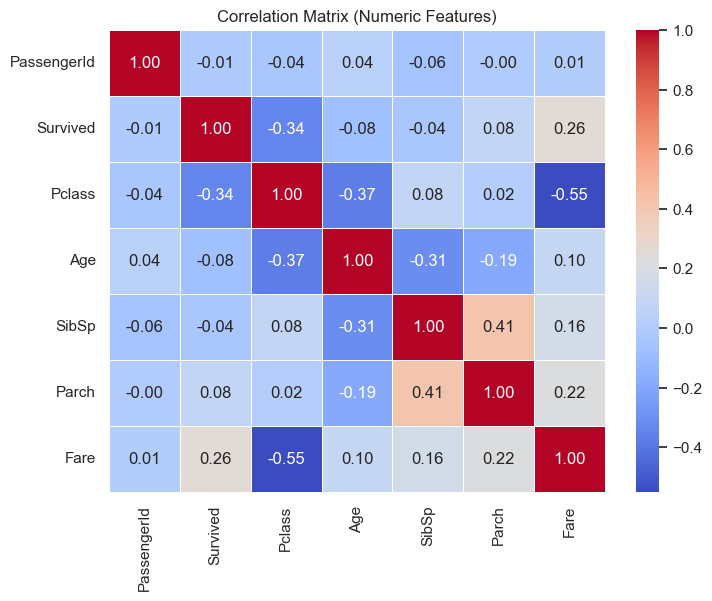

In [32]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

## 9. Pairplot for Feature Relationships

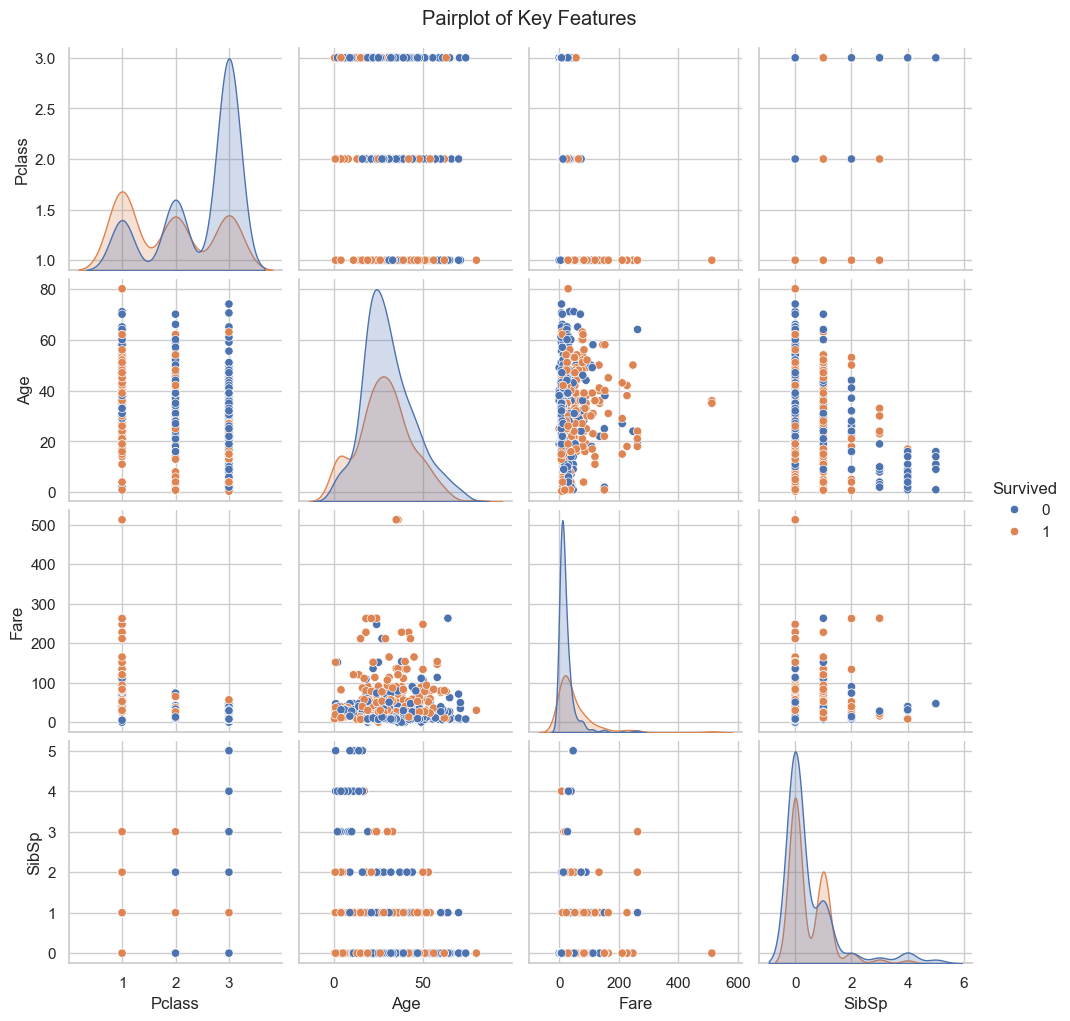

In [33]:
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp']].dropna(), hue='Survived')
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

## 10. Survival Rate by Categorical Features

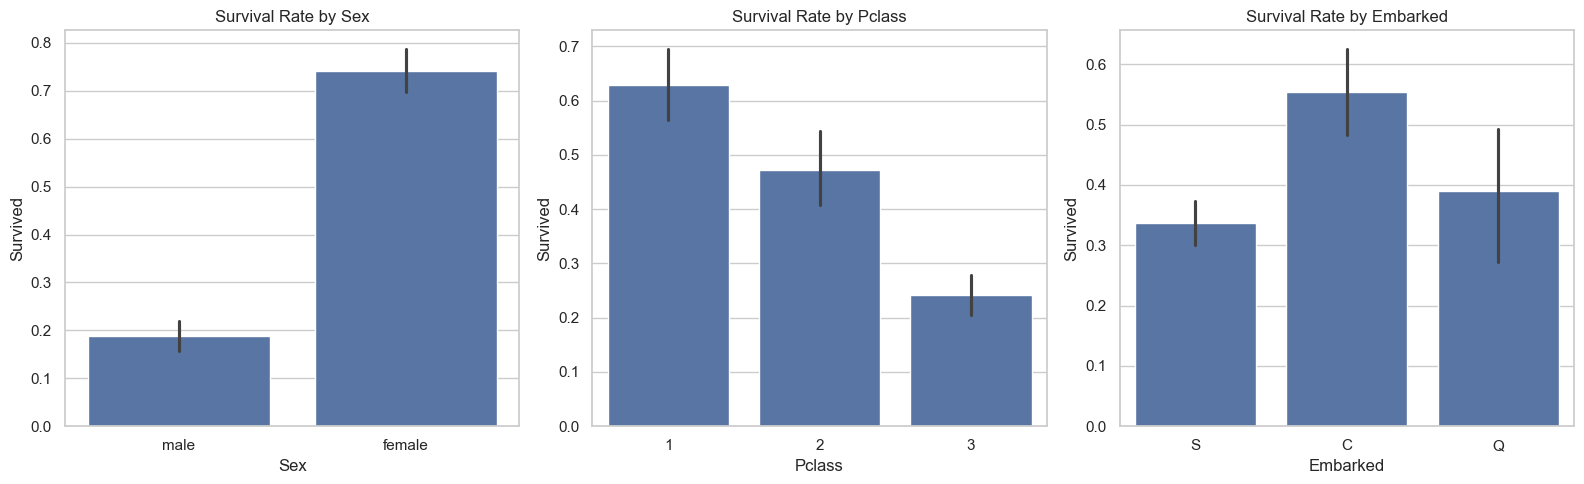

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1])
axes[1].set_title('Survival Rate by Pclass')
sns.barplot(data=df, x='Embarked', y='Survived', ax=axes[2])
axes[2].set_title('Survival Rate by Embarked')
plt.tight_layout()
plt.show()

## 11. Interactive Plotly Visualization

In [35]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat", "--upgrade"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


0

In [36]:
fig = px.histogram(df, x='Age', color='Survived', barmode='overlay',
                    nbins=30, title='Interactive Age Distribution by Survival')
fig.show()

In [37]:
fig = px.scatter(df, x='Age', y='Fare', color='Survived', size='Pclass',
                  hover_data=['Sex', 'Embarked'],
                  title='Age vs Fare colored by Survival')
fig.show()

## 12. Key Observations / Inferences

- **Survival & Sex:** Females had a noticeably higher survival rate than males.
- **Survival & Pclass:** 1st class passengers survived at a higher rate than 2nd and 3rd class — indicates class-based access to lifeboats.
- **Fare:** Right-skewed distribution with several high-fare outliers (visible in boxplot), correlating with Pclass and slightly with survival.
- **Age:** Roughly normal distribution with a concentration in the 20-40 range; missing values present (~20%) and need imputation for modeling.
- **SibSp/Parch:** Most passengers traveled alone (0 siblings/spouses or parents/children), with a long right tail.
- **Correlation:** `Fare` and `Pclass` show a moderate negative correlation (higher class number = lower fare). `Survived` correlates most with `Fare` (positive) and `Pclass` (negative) among numeric features.
- **Missing Data:** `Cabin` has a very high proportion of missing values; `Age` and `Embarked` have smaller amounts that can be imputed.